# Jules Verne Bot — Training the Transformer

Companion to `20_JulesVerneBot_Generating_English_Texts_with_RNN.ipynb`.
This notebook trains a **decoder-only Transformer** on the same ten novels,
with the **same character-level tokenizer (123 symbols)**, so that the only
thing that changes between the RNN and the Transformer is the architecture.

## The design that makes the comparison meaningful

Three variables separate a small RNN from a modern LLM: **architecture**,
**scale** and **tokenization**. Changing all three at once makes the result
uninterpretable, so this notebook holds tokenization fixed and varies the
other two deliberately:

| Run | Parameters | Context | What it isolates |
|---|---|---|---|
| RNN (existing) | 4,095,867 | 120 | baseline |
| `paired-ctx120` | 4,011,520 | 120 | **architecture only** — same size, same window |
| `paired` | 4,046,336 | 256 | architecture + longer context |
| `large` | 25,414,144 | 256 | **scale** |

Run `paired-ctx120` first if you want the single most defensible claim:
"at equal size and equal context, attention does/does not write better Verne."

> Runtime → Change runtime type → **GPU (T4)** before starting.


## 1. Environment

Colab already ships PyTorch. We only add `h5py` for the export format.


In [1]:
import sys
import importlib
import subprocess

# Colab already ships torch, numpy and h5py. We only need h5py for the export
# format, and it is normally present -- so check first and install only if it is
# genuinely missing.
#
# Do NOT pin h5py downwards here. ``h5py<3.12`` has no wheel for the Python
# version Colab now runs, so pip falls back to building it from source, which
# needs HDF5 C headers and fails. The old np.bool_ pin that motivated this is
# long fixed, so use whatever Colab provides.
try:
    import h5py
except ImportError:
    print('h5py missing -- installing...')
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py'])
    if result.returncode != 0:
        raise RuntimeError(
            'Could not install h5py. In Colab this normally means the runtime '
            'is mid-restart: use Runtime -> Restart session and run this cell again.'
        )
    h5py = importlib.import_module('h5py')

# Fail early and clearly here rather than halfway through a training run.
import numpy
import torch

print('python  ', sys.version.split()[0])
print('torch   ', torch.__version__)
print('numpy   ', numpy.__version__)
print('h5py    ', h5py.__version__)
print('cuda    ', torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

# The export path writes datasets and a JSON attribute; prove both work now.
import json
import os
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    probe = os.path.join(tmp, 'probe.h5')
    payload = numpy.zeros((2, 2), numpy.float32)
    with h5py.File(probe, 'w') as f:
        f.create_dataset('x', data=payload)
        f.attrs['config'] = json.dumps({'ok': True})
    with h5py.File(probe, 'r') as f:
        assert numpy.array_equal(f['x'][:], payload)
        assert json.loads(f.attrs['config'])['ok']

print('h5py export format: OK')


python   3.13.15
torch    2.11.0+cu128
numpy    2.1.3
h5py     3.16.0
cuda     True Tesla T4
h5py export format: OK


## 2. Get the project

The corpus, vocabulary builder and model definitions live in the project, so the
notebook stays thin and the exact same code trains on a GPU box.

**Option A -- clone a repository.** There is no public repo for this project yet,
so this is disabled by default. Publish one and set `REPO_URL` in the cell below.

**Option B -- upload a zip (default).** Zip the project folder and upload it. The
archive must contain `books/`, `vernebot/` and `train_transformer.py` at its top
level, or inside a single wrapping folder.

The cell verifies that all three are present and fails with a clear message if
not, instead of breaking halfway through training.


In [2]:
import os
import sys
import zipfile
from pathlib import Path

# ---------------------------------------------------------------------------
# Get the project into the Colab runtime.
#
# NOTE: there is no public repository for this project yet, so the clone path is
# disabled. Either publish one and put its URL in REPO_URL below, or upload a
# zip of the project folder (Option B, the default).
# ---------------------------------------------------------------------------
REPO_URL = None          # e.g. 'https://github.com/<user>/Jules_Verne.git'

# The project folder must contain: books/, vernebot/, train_transformer.py
REQUIRED = ['books', 'vernebot', 'train_transformer.py']


def find_project() -> Path | None:
    """Locate the project, whether cloned, uploaded, or already present.

    Checks /content (Colab) and the current directory with its parents, so the
    same notebook also runs from a local checkout.
    """
    roots = [Path('/content')]
    here = Path.cwd().resolve()
    roots += [here, *here.parents]

    for root in roots:
        if not root.is_dir():
            continue
        for candidate in (root / 'Jules_Verne', root):
            if all((candidate / r).exists() for r in REQUIRED):
                return candidate
        for candidate in sorted(root.glob('*')):
            if candidate.is_dir() and all((candidate / r).exists() for r in REQUIRED):
                return candidate
    return None


if REPO_URL:
    target = Path('/content/Jules_Verne')
    if not target.exists():
        print(f'Cloning {REPO_URL} ...')
        rc = os.system(f'git clone --depth 1 {REPO_URL} {target}')
        if rc != 0:
            print('Clone failed. Falling back to an upload.')
            REPO_URL = None

PROJECT = find_project()

if PROJECT is None and not REPO_URL:
    from google.colab import files
    print('Upload a ZIP of the whole project folder (it must contain books/,')
    print('vernebot/ and train_transformer.py):')
    uploaded = files.upload()
    for name in uploaded:
        if name.lower().endswith('.zip'):
            with zipfile.ZipFile(name) as z:
                z.extractall('/content')
            print(f'extracted {name}')
    PROJECT = find_project()

if PROJECT is None:
    raise RuntimeError(
        'Could not locate the project. Make sure the zip contains the books/, '
        'vernebot/ and train_transformer.py paths at its top level (or inside a '
        'single wrapping folder), then run this cell again.'
    )

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))

print()
print('project    :', PROJECT)
print('working dir:', Path.cwd())
print('books      :', len(list((PROJECT / 'books').glob('*.txt'))), 'novels')
print('modules    :', ', '.join(sorted(p.name for p in (PROJECT / 'vernebot').glob('*.py'))))


Upload a ZIP of the whole project folder (it must contain books/,
vernebot/ and train_transformer.py):


Saving Archive.zip to Archive (1).zip
extracted Archive (1).zip

project    : /content
working dir: /content
books      : 10 novels
modules    : __init__.py, engine.py, registry.py, text.py, transformer.py, transformer_model.py


## 3. The corpus and vocabulary

The tokenizer is rebuilt from `books/` exactly as the RNN notebook built it:
`sorted(set(text))` over the ten novels. It must stay at 123 characters, and the
training script refuses to run if it does not.


In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from vernebot.engine import build_vocabulary
from train_transformer import load_corpus

vocab = build_vocabulary()
text = load_corpus()

print(f'corpus : {len(text):,} characters')
print(f'vocab  : {len(vocab)} characters')
print(f'sample : {text[:180]!r}')
assert len(vocab) == 123, 'vocabulary changed -- the comparison is no longer fair'


corpus : 5,768,770 characters
vocab  : 123 characters
sample : '\ufeffThe Project Gutenberg eBook of A Journey to the Centre of the Earth\n    \nThis ebook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no '


## 4. The models

`paired` is 4,046,336 parameters against the RNN's 4,095,867 — a **1.2%**
difference, so neither model can win on size.


In [4]:
from vernebot.transformer_model import PAIRED, PAIRED_CONTEXT_120, LARGE, VerneTransformer

for label, cfg in (('paired-ctx120', PAIRED_CONTEXT_120),
                   ('paired', PAIRED),
                   ('large', LARGE)):
    n = VerneTransformer(cfg).parameter_count()
    print(f'{label:14s} ctx={cfg.context:4d} d_model={cfg.d_model:4d} '
          f'layers={cfg.n_layers} heads={cfg.n_heads}  ->  {n:>11,} params '
          f'({n / 4095867:.2f}x RNN)')


paired-ctx120  ctx= 120 d_model= 256 layers=5 heads=4  ->    4,011,520 params (0.98x RNN)
paired         ctx= 256 d_model= 256 layers=5 heads=4  ->    4,046,336 params (0.99x RNN)
large          ctx= 256 d_model= 512 layers=8 heads=8  ->   25,414,144 params (6.20x RNN)


## 5. Smoke test (about a minute)

A very short run on a small model to prove the whole path works — training,
export, and loading the result back with the NumPy inference engine — **before**
spending an hour on the real models. If this cell passes, the long runs will
produce something the website can serve.


In [5]:
from train_transformer import train
from vernebot.transformer import VerneTransformer as NumpyTransformer

summary = train(
    PAIRED, steps=300, batch_size=64, warmup=50, eval_every=100,
    sample_every=150, sample_length=200, out_path='models/smoke.h5',
)

# The website uses the NumPy engine, so verify it can read the export.
engine = NumpyTransformer.load('models/smoke.h5')
print('\nNumPy engine loaded the export:')
print('  params  :', f'{engine.parameter_count:,}')
print('  context :', engine.config.context)
print('\n  ' + ''.join(engine.generate('THE FLYING SUBMARINE', num_generate=200,
                                        temperature=0.7)).replace('\n', '\n  '))


device        : cuda
corpus        : 5,768,770 characters
vocab         : 123 characters
train / val   : 5,480,331 / 288,439
context       : 256
batch x steps : 64 x 300
parameters    : 4,046,336   (RNN baseline: 4,095,867 -- ratio 0.99x)
step      0/300  train 4.3756  val 4.3761  ppl    79.53  lr 6.00e-05  [4.9s]
step    100/300  train 2.4642  val 2.4763  ppl    11.90  lr 2.74e-03  [24.1s]

  --- sample at step 150 ---
  THE FLYING SUBMARINENCR gret hery wo ch thepeser, hand
  all ce of she m whatibes or the s cot tot, le waninged thontt ingast in whin abed the inghang
  ant tht cand ft, and ingly is ot wile ais inght thanes ind
  repergeees t

step    200/300  train 2.0366  val 2.0570  ppl     7.82  lr 1.23e-03  [45.0s]
step    299/300  train 1.8223  val 1.8503  ppl     6.36  lr 3.00e-04  [65.8s]

  --- sample at step 300 ---
  THE FLYING SUBMARINER WIII was ill MORMIFF
  GN
  ANEMOMGUI th LOR LORER
  
  
  
  
  The lakeed the to stiment; inden enutes trivers and be of I oppecing be

## 6. Train the size-matched model, same context as the RNN

The cleanest experiment: identical size, identical 120-character window. Any
difference in the output is attributable to attention versus recurrence.

Expect roughly 10–20 minutes on a T4.


In [6]:
summary_120 = train(
    PAIRED_CONTEXT_120,
    steps=6000, batch_size=64, lr=3e-3, warmup=300,
    eval_every=500, sample_every=2000, sample_length=400,
    out_path='models/tx-paired-ctx120.h5',
)


device        : cuda
corpus        : 5,768,770 characters
vocab         : 123 characters
train / val   : 5,480,331 / 288,439
context       : 120
batch x steps : 64 x 6000
parameters    : 4,011,520   (RNN baseline: 4,095,867 -- ratio 0.98x)
step      0/6000  train 4.7721  val 4.7756  ppl   118.58  lr 1.00e-05  [2.2s]
step    500/6000  train 1.6724  val 1.6889  ppl     5.41  lr 2.99e-03  [48.1s]
step   1000/6000  train 1.4058  val 1.4317  ppl     4.19  lr 2.90e-03  [93.0s]
step   1500/6000  train 1.3025  val 1.3271  ppl     3.77  lr 2.72e-03  [138.3s]

  --- sample at step 2000 ---
  THE FLYING SUBMARINEA would reach the result of this animal.
  In the moon of the traitors were convented a narrow in the other work, but the
  wind was answering for a mountain than provincing the sea. The engineer as
  the car ran for the strong which was but demonstrated to the torrent and
  points on the same tree. The repulsuon of the another bringing the case of
  the situation was able to send them. 


## 7. Train the size-matched model with a longer context

Same size again, but 256 characters of context instead of 120. Comparing this
with the previous run isolates the value of *context length* separately from
architecture — which is the honest way to show what attention buys you.


In [7]:
summary_256 = train(
    PAIRED,
    steps=6000, batch_size=64, lr=3e-3, warmup=300,
    eval_every=500, sample_every=2000, sample_length=400,
    out_path='models/tx-paired.h5',
)


device        : cuda
corpus        : 5,768,770 characters
vocab         : 123 characters
train / val   : 5,480,331 / 288,439
context       : 256
batch x steps : 64 x 6000
parameters    : 4,046,336   (RNN baseline: 4,095,867 -- ratio 0.99x)
step      0/6000  train 4.7645  val 4.7674  ppl   117.62  lr 1.00e-05  [5.1s]
step    500/6000  train 1.5422  val 1.5594  ppl     4.76  lr 2.99e-03  [107.6s]
step   1000/6000  train 1.2801  val 1.3077  ppl     3.70  lr 2.90e-03  [209.4s]
step   1500/6000  train 1.1842  val 1.2147  ppl     3.37  lr 2.72e-03  [311.0s]

  --- sample at step 2000 ---
  THE FLYING SUBMARINES LAST IN WHICH PROJECT GUTENBERG TO REACH A FULL PROJECT
  
  CHAPTER 49
  
  THE UNCAN TO LAND A FECT OF THE REEA.
  
  
  
  Verne
  
  The Mountains and Moulshy had been discovered by a certain flame. The
  following in the Indians were startled to the cross with the colonists, the
  provinces of the _Victoria_. The Caucasus was made them away by the time
  which the trees of the tr

## 8. Train the larger model (scale)

25.4M parameters, 6.2x the RNN. This is where the Transformer should pull
clearly ahead in coherence — and where the O(C^2) cost of attention starts to
be worth discussing against the RNN's O(1) per step.

Expect substantially longer; reduce `steps` if you are time-limited.


In [8]:
summary_large = train(
    LARGE,
    steps=12000, batch_size=48, lr=2e-3, warmup=500,
    eval_every=500, sample_every=3000, sample_length=400,
    out_path='models/tx-large.h5',
)


device        : cuda
corpus        : 5,768,770 characters
vocab         : 123 characters
train / val   : 5,480,331 / 288,439
context       : 256
batch x steps : 48 x 12000
parameters    : 25,414,144   (RNN baseline: 4,095,867 -- ratio 6.20x)
step      0/12000  train 4.6535  val 4.6563  ppl   105.25  lr 4.00e-06  [20.9s]
step    500/12000  train 1.5520  val 1.5774  ppl     4.84  lr 2.00e-03  [413.9s]
step   1000/12000  train 1.2268  val 1.2722  ppl     3.57  lr 1.99e-03  [808.1s]
step   1500/12000  train 1.1350  val 1.1728  ppl     3.23  lr 1.97e-03  [1200.6s]
step   2000/12000  train 1.0788  val 1.1209  ppl     3.07  lr 1.93e-03  [1593.0s]
step   2500/12000  train 1.0286  val 1.0979  ppl     3.00  lr 1.87e-03  [1985.3s]

  --- sample at step 3000 ---
  THE FLYING SUBMARINE FOR ANY PURPOSE THAT a ship was
  to be seen in one or two pounds of a horse, the threatened by chance of being
  cut, the “Yankee,” which had come to the thick and seals, of which
  extended the pole at the ground w

## 9. Compare the runs

Validation loss for the three Transformer runs, side by side.

*Corrected after the run:* this cell originally also drew a reference line at
0.45, labeled as the RNN's reported loss. That figure came from the course
notebook's text; its training log shows 30 epochs ending at a **training** loss
of 0.87, and there was no held-out loss for the RNN at all. The line has been
removed, and the figure below was regenerated from the same three run records
(`tx-*.json` in this folder) without it. Nothing else in this notebook changed.


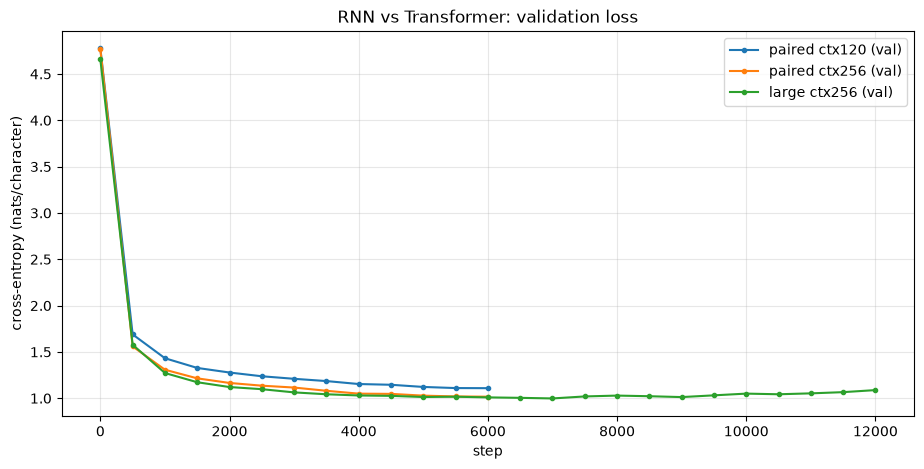

paired ctx120  params   4,011,520  val 1.0976  ppl    3.00  9.2 min
paired ctx256  params   4,046,336  val 1.0089  ppl    2.74  20.7 min
large ctx256   params  25,414,144  val 1.0834  ppl    2.95  158.5 min


In [9]:
import json, math
import matplotlib.pyplot as plt

runs = {}
for label, path in (('paired ctx120', 'models/tx-paired-ctx120.json'),
                    ('paired ctx256', 'models/tx-paired.json'),
                    ('large ctx256',  'models/tx-large.json')):
    p = Path(path)
    if p.exists():
        runs[label] = json.loads(p.read_text())

plt.figure(figsize=(11, 5))
for label, run in runs.items():
    steps = [h['step'] for h in run['history']]
    vals = [h['val'] for h in run['history']]
    plt.plot(steps, vals, marker='o', ms=3, label=f"{label} (val)")
plt.xlabel('step'); plt.ylabel('cross-entropy (nats/character)')
plt.title('RNN vs Transformer: validation loss'); plt.legend(); plt.grid(alpha=.3)
plt.show()

for label, run in runs.items():
    print(f"{label:14s} params {run['parameters']:>11,}  "
          f"val {run['final_val_loss']:.4f}  ppl {run['final_val_perplexity']:7.2f}  "
          f"{run['train_minutes']:.1f} min")


## 10. Same seed, same temperature, side by side

The most persuasive slide for the lecture. Both models get the identical prompt
and temperature.


In [10]:
from vernebot.transformer import VerneTransformer as NumpyTransformer
from vernebot import VerneRNN
import numpy as np

SEED = 'THE FLYING SUBMARINE'
TEMP = 0.7

print('=' * 78)
print('RNN (4.10M params, context 120)')
print('=' * 78)
try:
    rnn = VerneRNN.load()
    print(''.join(rnn.generate(SEED, num_generate=500, temperature=TEMP,
                               rng=np.random.default_rng(1))))
except FileNotFoundError as e:
    print('RNN weights not present in this environment:', e)

for label, path in (('pair', 'models/tx-paired.h5'), ('large', 'models/tx-large.h5')):
    if not Path(path).exists():
        continue
    print()
    print('=' * 78)
    engine = NumpyTransformer.load(path)
    cfg = engine.config
    print(f'{label} ({engine.parameter_count:,} params, context {cfg.context})')
    print('=' * 78)
    print(''.join(engine.generate(SEED, num_generate=500, temperature=TEMP,
                                 rng=np.random.default_rng(1))))


RNN (4.10M params, context 120)
RNN weights not present in this environment: Model not found: /content/models/verne_rnn_model.keras
Run `python export_model.py` from the notebook folder, or point VERNE_MODEL_PATH at your .keras file.

pair (4,046,336 params, context 256)
THE FLYING SUBMARINE REVERSED


On the 18th of February, the president of September, and the including
direction and posted the weight of the place of the projectile.

This was possible to the first experiment of the inhabitants of the
Antarctic Railways. The colonists saw him all the brig possessed and
strong at the corral, and the train crept along the corral soil with a little
surface of the sun. The rear of the crust now contains the least observation
of the travelers was here, for they were going to reach the 

large (25,414,144 params, context 256)
THE FLYING SUBMARINE FOREST


The distance which separated Alpha from the plateau from the point was
extended to a height of 23 miles. It was the engineer’s ork when h

## 11. Download the models for the website

Download these, then point the web app at them:

```bash
python generate_cli.py "THE FLYING SUBMARINE" --model models/tx-paired.h5
python run.py
```

Each `.h5` carries its own architecture config, tokenizer and training loss, so
the website needs no extra information to serve it.


In [11]:
from pathlib import Path

try:
    from google.colab import files
except ImportError:
    files = None
    print('Not running in Colab; files are already on disk.')

for name in ('tx-paired-ctx120', 'tx-paired', 'tx-large'):
    h5 = Path(f'models/{name}.h5')
    if h5.exists():
        print(f'{h5}  {h5.stat().st_size / 1e6:.1f} MB')
        if files is not None:
            files.download(str(h5))
        js = Path(f'models/{name}.json')
        if js.exists() and files is not None:
            files.download(str(js))


models/tx-paired-ctx120.h5  16.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

models/tx-large.h5  102.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What to say about this in class

1. **Architecture alone.** `paired-ctx120` vs the RNN is the controlled
   experiment: same 123-character vocabulary, same 120-character window, same
   4M parameters. Whatever changes is attention versus recurrence.
2. **Context alone.** `paired` vs `paired-ctx120` is the same architecture at
   two window sizes, so it isolates what long context buys.
3. **Scale.** `large` shows the effect that actually produced modern LLMs — and
   it is a *different* effect from the first two.
4. **Cost.** The RNN's hidden state gives O(1) work per generated character;
   attention is O(C) per character and O(C^2) to process a full window, growing
   quadratically during training. That trade is why the KV cache exists, and
   why this notebook's engine has to re-warm it when the window slides.
5. **Tokenization is the third axis**, deliberately held fixed here. Swapping to
   subword tokenization is the natural next lesson, and it is a separate one.
